2026-04-08 17:46:55.199584: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-08 17:46:55.199614: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-08 17:46:55.199649: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-08 17:46:55.199685: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 17:46:55.199702: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-08 17:46:56.071460: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Check Epoche  10 | Loss: 0.1689 | Val-Loss: 0.1537 | Aktuelle LR: 0.00100
  Check Epoche  20 | Loss: 0.1585 | Val-Loss: 0.1451 | Aktuelle LR: 0.00100
  Check Epoche  30 | Loss: 0.1527 | Val-Loss: 0.1448 | Aktuelle LR: 0.00100
  Check Epoche  40 | Loss: 0.1420 | Val-Loss: 0.1418 | Aktuelle LR: 0.00050
  Check Epoche  50 | Loss: 0.1370 | Val-Loss: 0.1394 | Aktuelle LR: 0.00050
  Check Epoche  60 | Loss: 0.1343 | Val-Loss: 0.1381 | Aktuelle LR: 0.00025
  Check Epoche  70 | Loss: 0.1261 | Val-Loss: 0.1346 | Aktuelle LR: 0.00013
  Check Epoche  80 | Loss: 0.1224 | Val-Loss: 0.1347 | Aktuelle LR: 0.00006
  Check Epoche  90 | Loss: 0.1223 | Val-Loss: 0.1339 | Aktuelle LR: 0.00003
  Check Epoche 100 | Loss: 0.1210 | Val-Loss: 0.1339 | Aktuelle LR: 0.00002

Metrik    Neuronales Netz   Lineare Regression
----------------------------------------------
MSE                0.2628               0.4495
RMSE               0.5126               0.6705
MAE                0.3369               0.4842
R2  

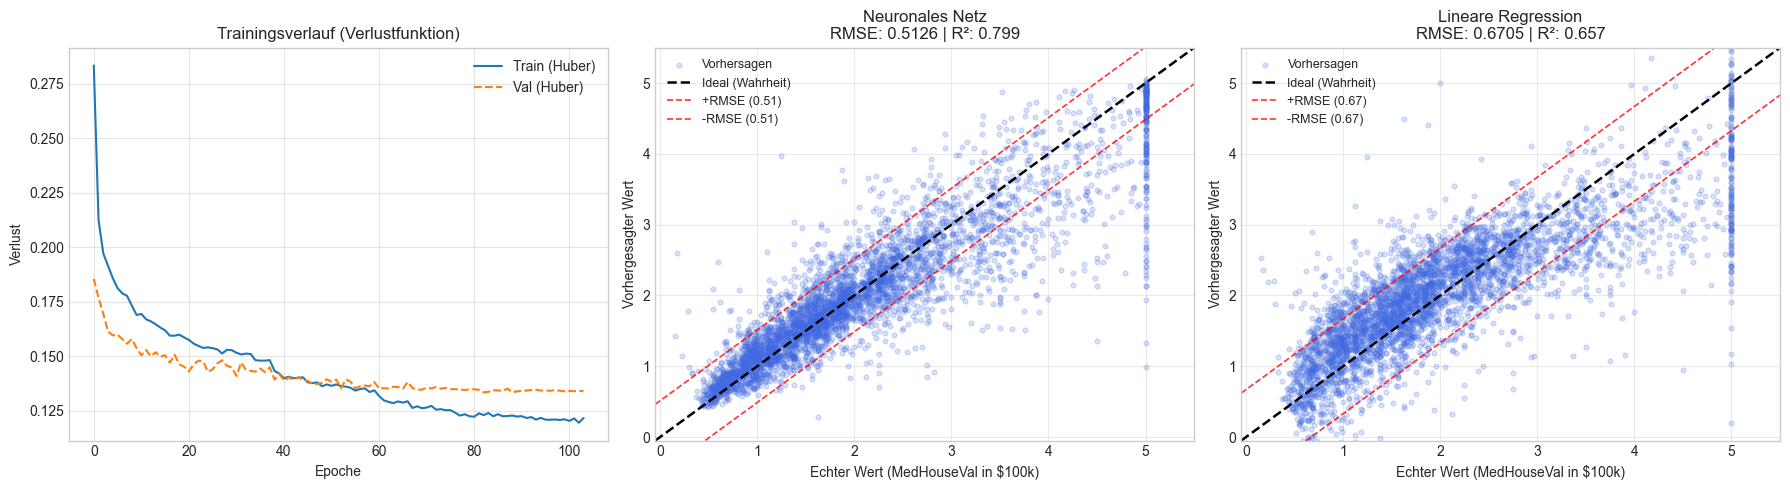

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score





# Setup & Seed für Reproduzierbarkeit
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)





# Teil 1: Daten laden und Feature Engineering
housing = fetch_california_housing(as_frame=True)
X, y = housing.data.copy(), housing.target.values

def engineer_features(df):
    """ Erstellt zusätzliche Features für bessere Vorhersagen """
    df = df.copy()
    # Verhältnisse und Pro-Kopf-Werte (Vermeidung von Division durch Null)
    df["income_per_room"]  = df["MedInc"] / (df["AveRooms"] + 1e-8)
    df["rooms_per_person"] = df["AveRooms"] / (df["AveOccup"] + 1e-8)
    df["bedroom_ratio"]    = df["AveBedrms"] / (df["AveRooms"] + 1e-8)
    
    # Geografische Distanzen zu Wirtschaftszentren (LA & San Francisco)
    df["dist_LA"] = np.sqrt((df["Latitude"] - 34.05)**2 + (df["Longitude"] + 118.24)**2)
    df["dist_SF"] = np.sqrt((df["Latitude"] - 37.77)**2 + (df["Longitude"] + 122.43)**2)
    
    # Log-Transformation für stark schiefe Verteilungen
    df["log_population"] = np.log1p(df["Population"])
    df["log_ave_occup"]  = np.log1p(df["AveOccup"])
    return df

X = engineer_features(X)

# Daten-Split (80% Training/Validation, 20% Test)
X_tv, X_test, y_tv, y_test = train_test_split(X.values, y, test_size=0.2, random_state=SEED)
# Validierungsset aus dem Trainingsset abspalten (10% von 80% = 8% Gesamt)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.1, random_state=SEED)

# Skalierung (Z-Score Normalisierung) basierend auf Trainingsdaten
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)





# Teil 2: Neuronales Netz Architektur (Deep Learning Model)
def build_nn(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_shape,)),
        
        # Block 1
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.15),

        # Block 2
        tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.10),

        # Block 3
        tf.keras.layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),

        # Output Layer für Regression (linear)
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(), # Robuster Loss gegen Ausreißer
        metrics=["mae"]
    )
    return model

# Eigener Callback für lesbare Konsolen-Ausgabe der Lernrate
class CustomProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            lr = float(self.model.optimizer.learning_rate)
            print(f"  Check Epoche {epoch+1:>3} | Loss: {logs['loss']:.4f} | Val-Loss: {logs['val_loss']:.4f} | Aktuelle LR: {lr:.5f}")

model = build_nn(X_train_s.shape[1])

# Training des Modells
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=250,
    batch_size=32, # Optimierte Batch-Größe für Effizienz --> Bessere Performance mit 64 oder 128
    callbacks=[
        # Stoppt, wenn val_loss sich 15 Epochen nicht verbessert
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        # Halbiert LR, wenn val_loss 7 Epochen stagniert
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=0.00001),
        CustomProgress()
    ],
    verbose=0 # Deaktiviert Standard-Keras-Output zugunsten des CustomCallbacks
)





# Teil 3: Auswertung & Vergleich mit Baseline
# Lineare Regression als klassische Baseline
lr_model = LinearRegression().fit(X_train_s, y_train)

# Vorhersagen auf Testdaten
y_nn = model.predict(X_test_s, verbose=0).flatten()
y_lr = lr_model.predict(X_test_s)

def calculate_metrics(y_true, y_pred):
    """ Berechnet Standard-Regressionsmetriken """
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

nn_results = calculate_metrics(y_test, y_nn)
lr_results = calculate_metrics(y_test, y_lr)

# Ergebnistabelle in der Konsole
print(f"\n{'Metrik':<8} {'Neuronales Netz':>16} {'Lineare Regression':>20}")
print("-" * 46)
for k in nn_results:
    print(f"{k:<8} {nn_results[k]:>16.4f} {lr_results[k]:>20.4f}")





# Teil 4: Visualisierung
plt.style.use('seaborn-v0_8-whitegrid') # Sauberer Plot-Stil
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Lernkurve (Train vs. Val Loss)
axes[0].plot(history.history["loss"], label="Train (Huber)")
axes[0].plot(history.history["val_loss"], label="Val (Huber)", linestyle="--")
axes[0].set_title("Trainingsverlauf (Verlustfunktion)")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Verlust")
axes[0].legend(); axes[0].grid(True, alpha=0.5)

# Gemeinsame Einstellungen für die Vorhersage-Plots
# Wir erweitern den Bereich etwas über 5 hinaus (+0.5)
plot_lim = [y_test.min() - 0.2, y_test.max() + 0.5] 
diag_line = np.linspace(plot_lim[0], plot_lim[1], 100)

for ax, pred, title in zip(axes[1:], [y_nn, y_lr], ["Neuronales Netz", "Lineare Regression"]):
    metrics = calculate_metrics(y_test, pred)
    rmse = metrics["RMSE"]
    r2 = metrics["R2"]
    
    # 1. Datenpunkte: Blau 
    ax.scatter(y_test, pred, alpha=0.2, s=12, color="royalblue", label="Vorhersagen")
    
    # 2. Ideallinie: Schwarz gestrichelt ("k--")
    ax.plot(diag_line, diag_line, "k--", linewidth=1.8, label="Ideal (Wahrheit)")
    
    # 3. Abweichungslinien: Rot gestrichelt ("r--")
    ax.plot(diag_line, diag_line + rmse, "r--", linewidth=1.2, alpha=0.8, label=f"+RMSE ({rmse:.2f})")
    ax.plot(diag_line, diag_line - rmse, "r--", linewidth=1.2, alpha=0.8, label=f"-RMSE ({rmse:.2f})")
    
    # Plot-Styling
    ax.set_title(f"{title}\nRMSE: {rmse:.4f} | R²: {r2:.3f}")
    ax.set_xlabel("Echter Wert (MedHouseVal in $100k)")
    ax.set_ylabel("Vorhergesagter Wert")
    
    # Achsenbereich festlegen
    ax.set_xlim(plot_lim)
    ax.set_ylim(plot_lim)
    
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()